# Lab: From Einstein Solids to Rubber Bands
## Computational Physics - Week 2

**Time:** ~2 hours  
**Goal:** Build computational skills for counting microstates, computing entropy, and understanding entropic forces.



## Setup

Run this cell first. If you get import errors, you may need to install scipy:
```
pip install scipy
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb  # For binomial coefficients
import math

# Make plots look nice
plt.rcParams['figure.figsize'] = [8, 5]
plt.rcParams['font.size'] = 12

print("Setup complete!")

Setup complete!


---
# Part 1: Counting Microstates (Einstein Solid)
**Time: ~25 minutes**

Recall from lecture: The number of ways to distribute $q$ quanta of energy among $N$ oscillators is:

$$\Omega(N, q) = \frac{(q + N - 1)!}{q! \, (N-1)!} = \binom{q + N - 1}{q}$$

This is the "stars and bars" combinatorics problem.

### 1.1 Warm-up: Using `scipy.special.comb`

The function `comb(n, k)` computes $\binom{n}{k} = \frac{n!}{k!(n-k)!}$

**Try it:** Compute $\binom{5}{2}$ (should be 10)

In [ ]:
# Example: C(5,2) = 5!/(2!*3!) = 10
result = comb(5, 2, exact=True)  # exact=True gives integer result
print(f"C(5,2) = {result}")

# YOUR TURN: Compute C(10, 3) - should be 120

C(5,2) = 10


### 1.2 Write the Einstein Solid Ω Function

**Task:** Complete the function below to compute Ω(N, q) for the Einstein solid.

Remember: $\Omega = \binom{q + N - 1}{q}$

In [ ]:
def omega_einstein(N, q):
    """
    Number of microstates for an Einstein solid.

    Parameters:
        N: number of oscillators
        q: number of energy quanta

    Returns:
        Omega: number of microstates
    """
    # FILL IN: Use comb() to compute the binomial coefficient
    # Hint: You need comb(something, something, exact=True)
    Omega = comb(q+N-1, q, exact = True)



    return Omega

### 1.3 Test Your Function

Let's verify with the example from lecture: 3 oscillators, 4 quanta → 15 ways

In [ ]:
omega = omega_einstein(3, 4)
print(f"Ω(3, 4) = {omega}")

Ω(3, 4) = 15


### Checkpoint 1

If both tests pass, you've successfully implemented the microstate counting function!

**Connection to HW:** In your homework, you'll write a similar function `num_configurations(L, N)` for the polymer. The math is different (binomial coefficient for choosing which links point right), but the pattern is the same.

---
# Part 2: Visualizing Ω and Working with Large Numbers
**Time: ~20 minutes**

When N and q get large, Ω becomes *astronomically* large. This is why we use logarithms!

### 2.1 The Problem with Big Numbers

In [ ]:
# Let's see how big omega gets
print("N=3, q=4:", omega_einstein(3, 4))
print("N=10, q=10:", omega_einstein(10, 10))
print("N=100, q=100:", omega_einstein(100, 100))

# This one is HUGE
big_omega = omega_einstein(300, 100)
print(f"\nN=300, q=100: {big_omega}")
print(f"That's a number with {len(str(big_omega))} digits!")

N=3, q=4: 15
N=10, q=10: 92378
N=100, q=100: 45274257328051640582702088538742081937252294837706668420660

N=300, q=100: 1681391093665753171442407790401273916134058383107221992799956694172009755572270420514201330380740
That's a number with 97 digits!


### 2.2 Two Blocks in Contact

From lecture: When two blocks share energy, we multiply their Ω values.

If block 1 has $q_1$ quanta and block 2 has $q_2 = q_{total} - q_1$ quanta:
$$\Omega_{total}(q_1) = \Omega_1(q_1) \times \Omega_2(q_{total} - q_1)$$

**Task:** Fill in the function and plot Ω_total vs q₁

<>:27: SyntaxWarning: invalid escape sequence '\O'
<>:27: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipython-input-3777955968.py:27: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel('$\Omega_{total}$')


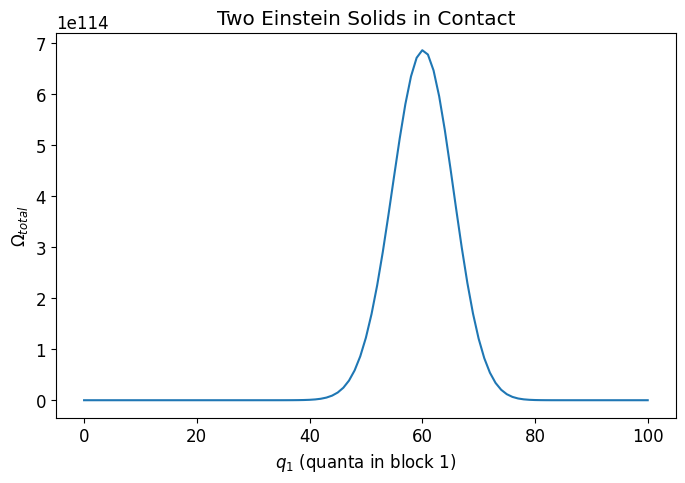

In [ ]:
def omega_total_two_blocks(N1, N2, q_total, q1):
    """
    Total microstates when block 1 has q1 quanta and block 2 has the rest.
    """
    Omega1 = omega_einstein(N1, q1)
    Omega2 = omega_einstein(N2, q_total - q1)
    return Omega1 * Omega2

# Parameters from lecture: 300 oscillators + 200 oscillators, 100 quanta total
N1 = 300
N2 = 200
q_total = 100

# Compute Omega_total for all possible distributions
#ask for hint if needed
q1_values = [0] * (q_total + 1)
omega_values = [0] * (q_total + 1)
for q1 in range(0, q_total + 1, 1):
  q1_values[q1] = q1
  omega_values[q1] = omega_total_two_blocks(N1, N2, q_total, q1)


# Plot
plt.figure()
plt.plot(q1_values, omega_values)
plt.xlabel('$q_1$ (quanta in block 1)')
plt.ylabel('$\Omega_{total}$')
plt.title('Two Einstein Solids in Contact')
plt.show()

### 2.3 Using a Log Scale

The y-axis is hard to read because Ω varies over many orders of magnitude.

**Task:** Remake the plot with a logarithmic y-axis using `plt.yscale('log')`

<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipython-input-3508216966.py:5: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel('$\Omega_{total}$')


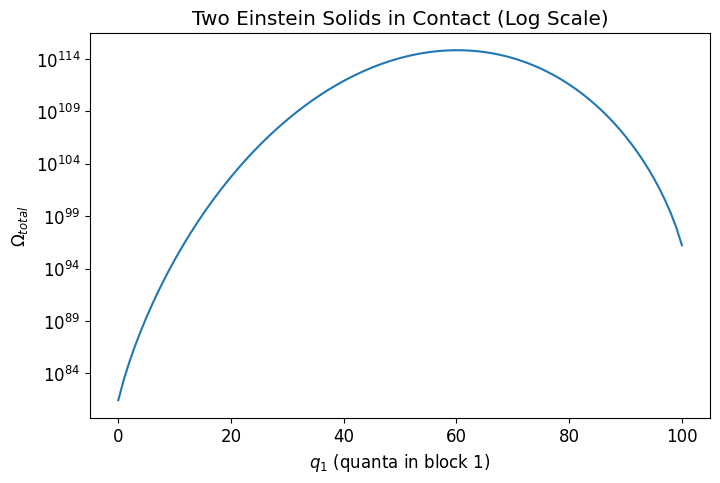

Most probable: q1 = 60 quanta in block 1
This means q2 = 40 quanta in block 2


In [ ]:
# Same plot but with log scale
plt.figure()
plt.plot(q1_values, omega_values)
plt.xlabel('$q_1$ (quanta in block 1)')
plt.ylabel('$\Omega_{total}$')
plt.title('Two Einstein Solids in Contact (Log Scale)')

# FILL IN: Add the log scale
plt.yscale('log')  # <-- ADD THIS LINE

plt.show()

# Find the most probable distribution
max_index = np.argmax(omega_values)
print(f"Most probable: q1 = {q1_values[max_index]} quanta in block 1")
print(f"This means q2 = {q_total - q1_values[max_index]} quanta in block 2")

### 2.4 Question

The most probable distribution has q₁ = 60 for the block with 300 oscillators.

**Think about it:** Why does the bigger block get more energy at equilibrium? (Answer in terms of "energy per oscillator")

###  Checkpoint 2

You can now:
- Compute Ω for combined systems
- Use log scales to visualize quantities that span many orders of magnitude

**Connection to HW Task 2.2:** You'll make a similar log-scale plot of Ω(L) for the polymer.

---
# Part 3: Entropy
**Time: ~20 minutes**

Entropy is the logarithm of the number of microstates:

$$S = k_B \ln \Omega$$

For computational convenience, we often measure entropy in **bits**:

$$S_{bits} = \log_2 \Omega$$

### 3.1 Write an Entropy Function

In [ ]:
def entropy_einstein(N, q):
    """
    Entropy (in bits) for an Einstein solid.

    Returns:
        S: entropy in bits (using log base 2)
    """
    Omega = omega_einstein(N, q)

    # Handle edge case: if Omega = 0, entropy is undefined (or -infinity)
    if Omega <= 0:
        return 0  # By convention for our purposes
    S = np.log2(float(Omega))
    # FILL IN: Compute entropy using np.log2()

    return S

# Test
print(f"S(N=3, q=4) = {entropy_einstein(3, 4):.3f} bits")
print(f"Expected: log2(15) = {np.log2(15):.3f} bits")

S(N=3, q=4) = 3.907 bits
Expected: log2(15) = 3.907 bits


### 3.2 Entropy Adds When Systems Combine

One beautiful property of entropy: when you combine independent systems, entropies **add**.

$$S_{total} = S_1 + S_2$$

This is because $\Omega_{total} = \Omega_1 \times \Omega_2$, and $\log(ab) = \log(a) + \log(b)$.

In [ ]:
# Verify this property
N1, q1 = 10, 5
N2, q2 = 8, 3

S1 = entropy_einstein(N1, q1)
S2 = entropy_einstein(N2, q2)
S_sum = S1 + S2
Omega1 = omega_einstein(N1, q1)
Omega2 = omega_einstein(N2, q2)
S_from_product = np.log2(Omega1 * Omega2)
# Compare to computing S from the product of Omegas
#then print using these or other method
print(f"S1 + S2 = {S_sum:.6f} bits")
print(f"log2(Ω1 × Ω2) = {S_from_product:.6f} bits")
print(f"Difference: {abs(S_sum - S_from_product):.2e}")

S1 + S2 = 17.874117 bits
log2(Ω1 × Ω2) = 17.874117 bits
Difference: 0.00e+00


### 3.3 Plot Total Entropy vs Energy Distribution

IndexError: list index out of range

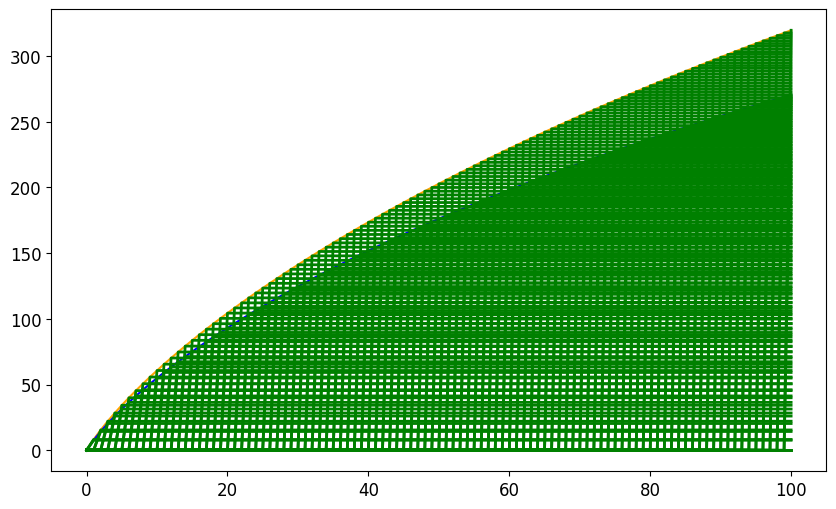

In [ ]:

# Two blocks: 300 and 200 oscillators, 100 quanta total

N1 = 300
N2 = 200
q_total = 100

S1_values = [0]*(q_total + 1)



S2_values = [0]*(q_total + 1)
S_total = [0]*(q_total + 1)
q1_values = [0]*(q_total + 1)# finish
for i in range(0, q_total + 1, 1):
  q1_values[i] = i
  S1_values[i] = entropy_einstein(N1, i)
  S2_values[i] = entropy_einstein(N2, i)
  S_total[i] = S1_values + S2_values
# Plot all three
plt.figure(figsize=(10, 6))
plt.plot(q1_values, S1_values, label='$S_1$ (300 oscillators)', color='orange')
plt.plot(q1_values, S2_values, label='$S_2$ (200 oscillators)', color='blue')
plt.plot(q1_values, S_total, label='$S_{total} = S_1 + S_2$', color='green', linewidth=2)

# Mark maximum
max_idx = np.argmax(S_total)
plt.axvline(q1_values[max_idx], color='gray', linestyle='--', alpha=0.5)
plt.scatter([q1_values[max_idx]], [S_total[max_idx]], color='red', s=100, zorder=5)

plt.xlabel('$q_1$ (quanta in block 1)')
plt.ylabel('Entropy (bits)')
plt.title('Entropy Maximization Determines Equilibrium')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Maximum total entropy at q1 = {q1_values[max_idx]}")

###  Checkpoint 3

Key insight: **Systems evolve toward maximum entropy.** The equilibrium distribution is where S_total is maximized.

**Connection to HW Tasks 3.1-3.2:** You'll write `entropy(L, N)` for the polymer, which works the same way: S = log₂(Ω).

---
# Part 4: Numerical Derivatives (Temperature and Force)
**Time: ~20 minutes**

Temperature is defined as:
$$\frac{1}{T} = \frac{\partial S}{\partial E}$$

And entropic force is:
$$F = -T \frac{\partial S}{\partial L}$$

We'll compute these numerically using **finite differences**.

### 4.1 Finite Difference Derivatives

The derivative of f(x) can be approximated as:

$$\frac{df}{dx} \approx \frac{f(x + \Delta x) - f(x - \Delta x)}{2 \Delta x}$$

This is called the **central difference** formula.

In [ ]:
# Example: derivative of x^2 at x=3 (should be 2*3 = 6)

def f(x):
    return x**2

x = 3
dx = 0.01  # Small step size

# Central difference
derivative = (f(x + dx) - f(x - dx)) / (2 * dx)

print(f"Numerical derivative of x² at x=3: {derivative}")
print(f"Exact answer: 6")

Numerical derivative of x² at x=3: 5.999999999999872
Exact answer: 6


### 4.2 Compute dS/dq for the Einstein Solid

Since energy comes in quanta, the smallest step is Δq = 1.

In [ ]:
def dS_dq(N, q, dq=1):
    """
    Numerical derivative of entropy with respect to quanta.

    Returns dS/dq in bits per quantum.
    """
    # FILL IN: Use central difference formula
    derivative = (entropy_einstein(N, q + dq) - entropy_einstein(N, q - dq)) / (2 * dq)
    return derivative

# Test: compute dS/dq for various q values
N = 300
q_values = [10, 30, 50, 70, 90]

print(f"{'q':>5} {'dS/dq (bits/quantum)':>22}")
print("-" * 30)
for q in q_values:
    deriv = dS_dq(N, q)
    print(f"{q:>5} {deriv:>22.4f}")

    q   dS/dq (bits/quantum)
------------------------------
   10                 4.8831
   30                 3.4336
   50                 2.7910
   70                 2.3899
   90                 2.1057


### 4.3 The Meaning of dS/dq

Notice that dS/dq **decreases** as q increases. This makes physical sense:

- A cold object (low energy) has a steep S vs E curve → large dS/dE → low temperature
- A hot object (high energy) has a shallow S vs E curve → small dS/dE → high temperature

Since $1/T = dS/dE$, higher dS/dE means lower temperature.

**This is exactly how heat flows from hot to cold!** Energy moves from low dS/dE (hot) to high dS/dE (cold) because this increases total entropy.

###  Checkpoint 4

You can now compute numerical derivatives using finite differences.

**Connection to HW Task 4.2:** You'll use the same technique to compute the entropic force:

$$F(L) \approx -T \frac{S(L + \Delta L) - S(L - \Delta L)}{2 \Delta L}$$

The homework tells you to use ΔL = 2d (the smallest physical change in polymer length).

---
# Part 5: The Polymer Model
**Time: ~30 minutes**

Now let's switch from the Einstein solid to the **polymer** (rubber band) model from your homework.



- A polymer is a chain of N links, each of length d
- Each link points either right (+1) or left (-1)
- The end-to-end length is: $L = d \sum_{i=1}^{N} s_i$

If $n_+$ links point right and $n_- = N - n_+$ point left:
$$L = d(n_+ - n_-) = d(2n_+ - N)$$

### 5.1 From L to n₊

**Task:** Solve for n₊ in terms of L, N, and d.

Starting from $L = d(2n_+ - N)$:

$$n_+ = \frac{L/d + N}{2}$$

In [ ]:
def n_plus_from_L(L, N, d=1):
    """
    Calculate the number of right-pointing links from the end-to-end length.
    """
    # FILL IN: Implement the formula n_+ = (L/d + N) / 2
    n_plus = (L/d + N) / 2
    return int(n_plus)  # Must be an integer

# Test with N=5, d=1
# If all links point right: L = 5, so n_+ should be 5
# If all links point left: L = -5, so n_+ should be 0
# If balanced: L = 1, so n_+ should be 3 (3 right, 2 left)

### 5.2 Counting Polymer Configurations

The number of ways to choose which $n_+$ links point right (out of N total) is:

$$\Omega(L) = \binom{N}{n_+}$$

**Task:** Complete this function

In [ ]:
def num_configurations_polymer(L, N, d=1):
    """
    Number of polymer configurations with end-to-end length L.

    Parameters:
        L: end-to-end length (must have correct parity)
        N: number of links
        d: length of each link

    Returns:
        Omega: number of configurations
    """
    # Step 1: Get n_plus from L
    n_plus = n_plus_from_L(L, N)

    # Step 2: Check if n_plus is a valid integer
    if (n_plus < 0):
      return 0

    # Step 3: Check if n_plus is in valid range
    if (n_plus > N):
      return 0

    # Step 4: Compute binomial coefficient
    # FILL IN: Return C(N, n_plus)
    return comb(N, n_plus)


# Test cases from homework
N = 100

print("Testing polymer Ω function:")
print(f"Ω(L=N={N}): {num_configurations_polymer(N, N)} (expected 1 - all right)")
print(f"Ω(L=-N={-N}): {num_configurations_polymer(-N, N)} (expected 1 - all left)")
print(f"Ω(L=0): {num_configurations_polymer(0, N):.3e} (expected ~1.01e29)")

Testing polymer Ω function:
Ω(L=N=100): 1.0 (expected 1 - all right)
Ω(L=-N=-100): 1.0 (expected 1 - all left)
Ω(L=0): 1.009e+29 (expected ~1.01e29)


### 5.3 Plot Ω(L) for the Polymer

**Important:** L can only take values with the same parity as N (both even or both odd).

For N=100 (even), L can be: -100, -98, -96, ..., 96, 98, 100

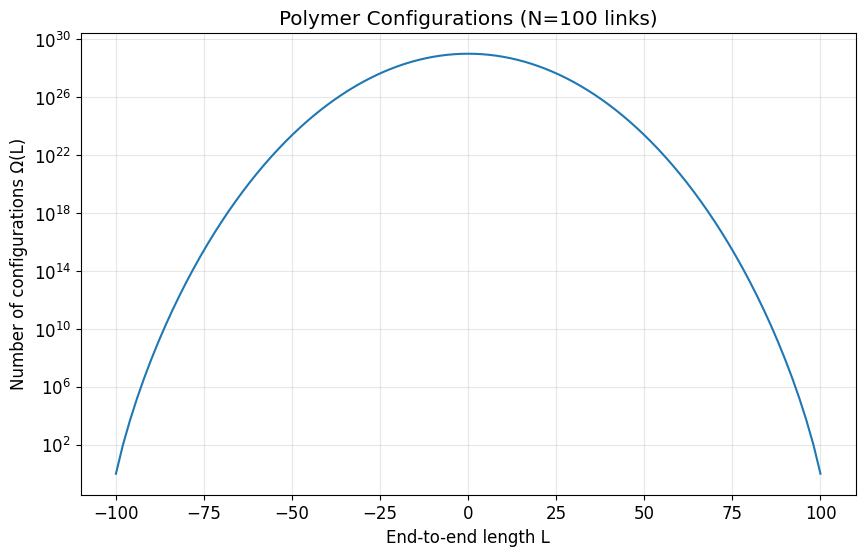

Ω is maximized at L = 0
Ω(L=0) / Ω(L=N) = 1.01e+29
That's about 29 orders of magnitude!


In [ ]:
N = 100
d = 1

# Generate all valid L values (step of 2 because parity must match)
L_values = np.arange(-N, N + 1, 2)  # -100, -98, ..., 98, 100
Omega_values = [0] * len(L_values)
# Compute Ω for each L
for i in range(0, len(L_values), 1):
  Omega_values[i] = num_configurations_polymer(L_values[i], N)


# Plot with log scale
plt.figure(figsize=(10, 6))
plt.semilogy(L_values, Omega_values)  # semilogy = log y-axis, linear x-axis
plt.xlabel('End-to-end length L')
plt.ylabel('Number of configurations Ω(L)')
plt.title(f'Polymer Configurations (N={N} links)')
plt.grid(True, alpha=0.3)
plt.show()

# Answer homework question
print(f"Ω is maximized at L = {L_values[np.argmax(Omega_values)]}")
print(f"Ω(L=0) / Ω(L=N) = {num_configurations_polymer(0, N) / num_configurations_polymer(N, N):.2e}")
print(f"That's about {np.log10(num_configurations_polymer(0, N) / num_configurations_polymer(N, N)):.0f} orders of magnitude!")

### 5.4 Entropy and Entropic Force

Now let's compute entropy and the entropic force

In [ ]:
def entropy_polymer(L, N, d=1):
    """Entropy in bits for polymer with length L."""
    Omega = num_configurations_polymer(L, N)
    #code here
    return np.log2(float(Omega))

def force_polymer(L, N, d=1, T=1):
    """
    Entropic force on polymer at length L.

    F = -T * dS/dL

    We use ΔL = 2d (smallest possible change in L)
    """
    dL = 2 * d  # Smallest step

    # FILL IN: Compute force using central difference
    dSdL = (entropy_polymer(L + dL, N) - entropy_polymer(L - dL, N)) / (2 * dL)
    F = T * dSdL


    return F

# Compute entropy and force
N = 100
d = 1
L_values = np.arange(-N + 2, N - 1, 2)  # Avoid edges for derivative

S_values = [entropy_polymer(L, N, d) for L in L_values]
F_values = [force_polymer(L, N, d) for L in L_values]

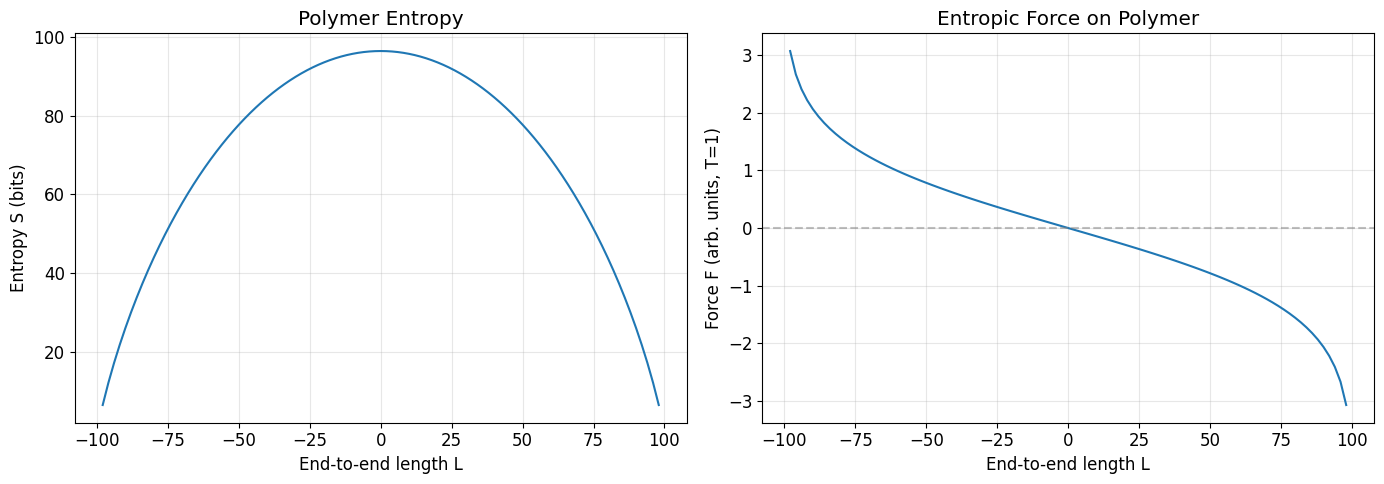

In [ ]:
# Plot entropy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Entropy plot
axes[0].plot(L_values, S_values)
axes[0].set_xlabel('End-to-end length L')
axes[0].set_ylabel('Entropy S (bits)')
axes[0].set_title('Polymer Entropy')
axes[0].grid(True, alpha=0.3)

# Force plot
axes[1].plot(L_values, F_values)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('End-to-end length L')
axes[1].set_ylabel('Force F (arb. units, T=1)')
axes[1].set_title('Entropic Force on Polymer')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.5 Interpret the Force

Look at the force plot:

1. When L > 0 (stretched to the right), F < 0 (force pulls left)
2. When L < 0 (stretched to the left), F > 0 (force pulls right)
3. When L ≈ 0, F ≈ 0 (no net force)

**The polymer always wants to contract back toward L = 0!**

This is the **entropic force** that makes rubber bands snap back.

---
## Optional Challenge: Why Do Rubber Bands Get Stiffer When Heated?

From the Gaussian approximation (HW Task 3.3), the spring constant is:

$$k = \frac{T}{N d^2 \ln 2}$$

Notice that k is **proportional to T**!

- Higher temperature → stiffer rubber band
- This is **opposite** to a metal spring (which gets softer when heated)

Why? Because the restoring force is *entropic*, not energetic. Higher T means entropy matters more, so the system fights harder to return to the high-entropy (L≈0) state.